# Setup

## Load Packages

In [2]:
library(tidyverse)
library(AICcmodavg)
library(lemon)
library(ggpubr)
library(grid)
library(lmerTest)
library(emmeans)
library(car)
library(cowplot)
library(ggplot2)
library(DescTools)

#Change plot dimensions
options(repr.plot.width=16, repr.plot.height=8) 

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lme4

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lme4’


The following object is masked from ‘package:AICcmodavg’:

    checkConv



Attaching package: ‘lmerTest’


The following objec

## Define palettes

In [3]:
condition_colors <- c("20S" = '#6EE2FFFF', "P" = '#F7C530FF', "37S" = '#FF410DFF', "25S" = "#0E9C3F", "A" = "white")
condition_colors
condition_names <- c("20S" = "20°C Constant",
                    "37S" = "37°C Constant",
                    "P" = "Fluctuating", 
                    "A" = "Ancestor",
                    "25S" = "25°C Control", 
                    "20" = "20°C", 
                    "37" = "37°C")

condition_lines <- c("20S" = "dotdash", "P" = "solid", "37S" = "31", "25S" = "11", "A" = "solid")


20S           P         37S         25S           A 
"#6EE2FFFF" "#F7C530FF" "#FF410DFF"   "#0E9C3F"     "white"

## Import and wrangle data

In [4]:
HE_data <- read.csv("../Data_Processing/HE_area_table_additive.csv")
HE_data <- HE_data %>% mutate(Condition = factor(Condition, levels = c("25S", "20S", "P", "37S")), 
                 Temperature = factor(Temperature), 
                 Colony = factor(Colony), 
                 Rep = factor(Rep))
head(HE_data)

,Days,FA,Condition,Temperature,Colony,Rep,OD,Area
,<dbl>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>
1,0.0000000,1,37S,37,1,1,0.074,0.000
2,0.3333333,1,37S,37,1,1,0.407,1.924
3,1.0000000,1,37S,37,1,1,1.296,15.548
4,1.3333333,1,37S,37,1,1,1.194,25.508
5,2.0000000,1,37S,37,1,1,1.151,44.268
6,2.3333333,1,37S,37,1,1,1.144,53.448


In [5]:
# Normalize the data
HE_data_norm <- data.frame()
conditions <- unique(HE_data$Condition)
for (assay in c(1, 5:10)){
    
    #subset the FA for just day 4
    HE_data_temp <- HE_data %>% filter(FA == assay, Days == 4)
    
    # Get the mean and median of the 25S over each colony and rep for each temperature
    # Since the first assay didn't have a 25S but they're all the same can use P as a proxy:
    condition_filt = "25S"
    if (assay == 1){ condition_filt = "P" }
    stats_25S <- HE_data_temp %>% 
                    filter(Condition == condition_filt) %>% 
                    group_by(Temperature) %>% 
                    summarize(Mean = mean(Area), Median = median(Area)) %>% 
                    data.frame()

    HE_data_norm <- HE_data_temp %>% 
                    group_by(Condition, Temperature) %>%
                    arrange(Temperature) %>%
                    mutate(FA = assay, Norm = case_when(Temperature == 20 ~ Area/stats_25S[stats_25S$Temperature == 20, "Median"], 
                                                        Temperature == 37 ~ Area/stats_25S[stats_25S$Temperature == 37, "Median"])) %>%
                    rbind(HE_data_norm)
}

dim(HE_data_norm)
head(HE_data_norm)

[1] 3240    9

Days,FA,Condition,Temperature,Colony,Rep,OD,Area,Norm
<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
4,10,20S,20,1,1,1.638,89.992,1.339765
4,10,20S,20,1,2,1.550,87.088,1.296531
4,10,20S,20,1,3,1.526,90.032,1.340360
4,10,20S,20,1,4,1.307,87.624,1.304511
4,10,20S,20,1,5,1.321,79.484,1.183326
4,10,20S,20,2,1,1.194,88.876,1.323150


# Display the overall data
## Timecourse data

`summarise()` has grouped output by 'FA', 'Condition'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'FA', 'Condition', 'Temperature'. You can override using the `.groups` argument.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


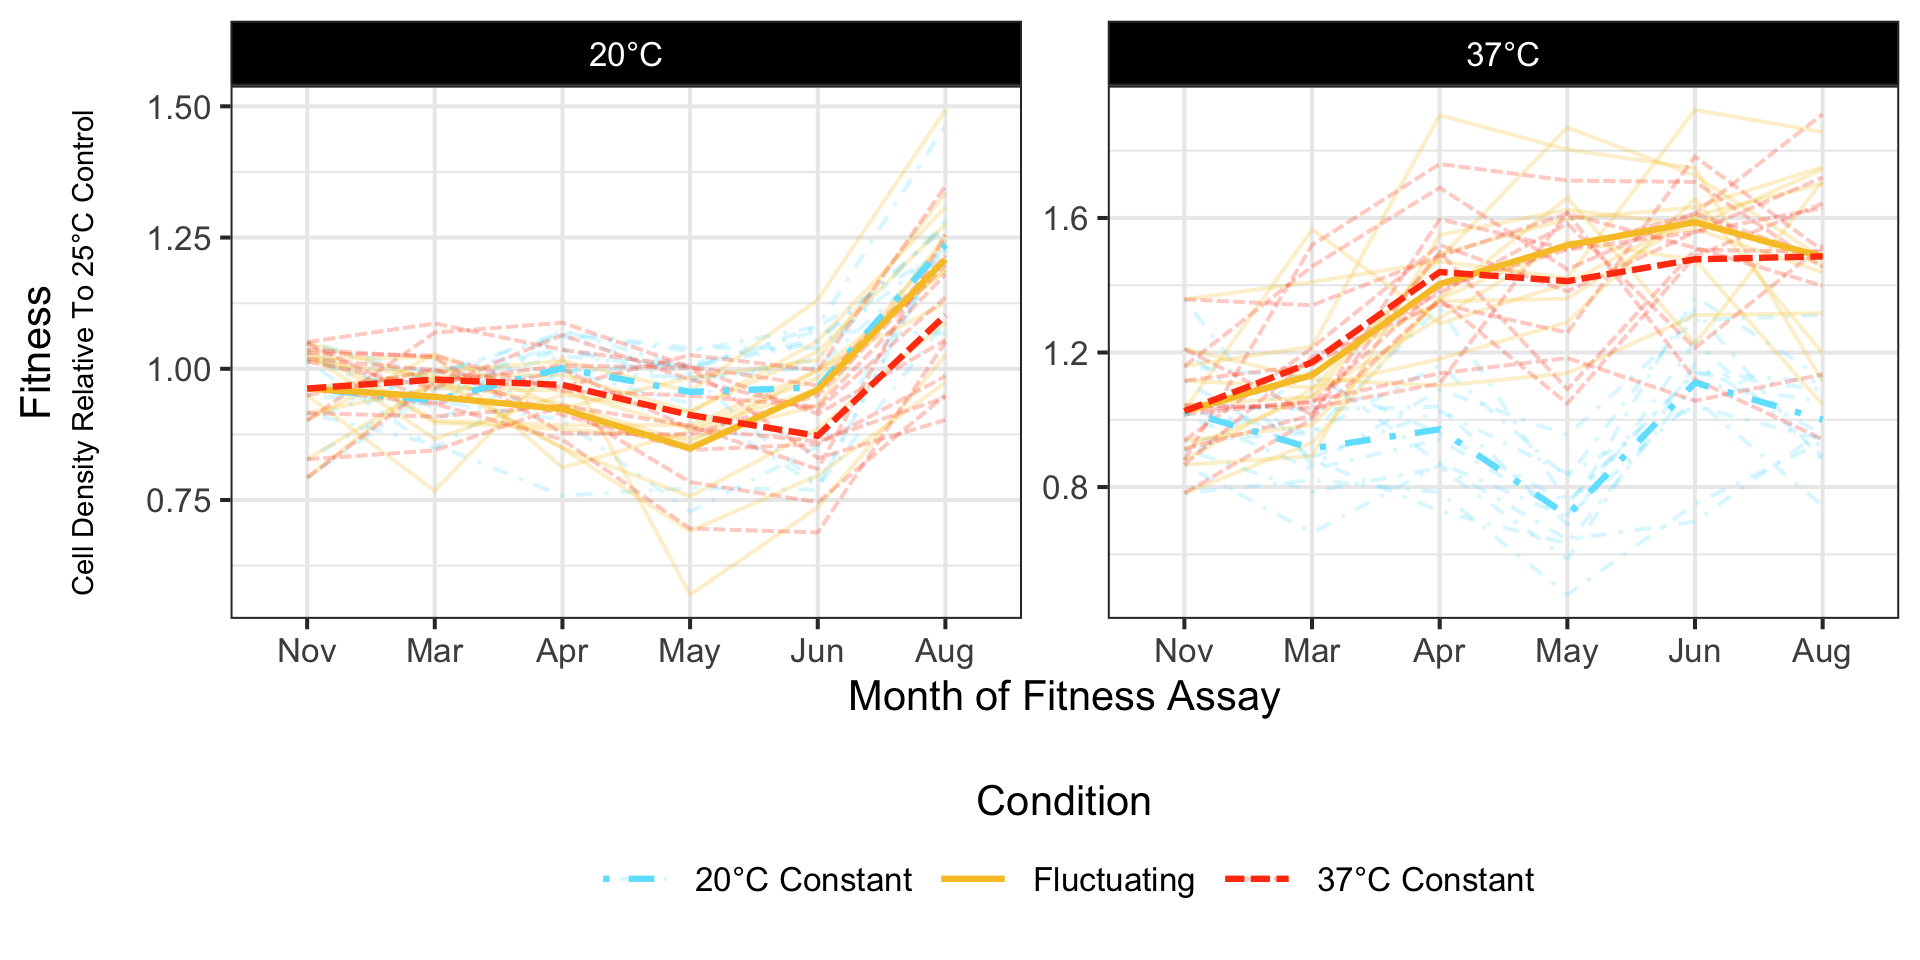

In [6]:
# Get general average of all the colonies
average_fitness <-  HE_data_norm %>% 
                    filter(FA %in% c(1, 5:9), Days == 4, Condition != "25S") %>%
                    group_by(FA, Condition, Temperature) %>%
                    summarise(avg_cond = mean(Norm))

# Get average per colony
average_fitness_col <-  HE_data_norm %>% 
                    filter(FA %in% c(1, 5:9), Days == 4, Condition != "25S") %>%
                    group_by(FA, Condition, Temperature, Colony) %>%
                    summarise(avg_col = mean(Norm))

HE_Plot <- average_fitness_col %>% 
    ggplot(aes(x = factor(FA), y = avg_col, col = Condition, linetype = Condition, group = interaction(Colony, Condition)))+
        theme_bw(25)+ #25 paper
        facet_wrap(~Temperature, labeller = as_labeller(condition_names), ncol = 2, scales = "free")+ #ncol 1 poster
        geom_line(alpha = 0.25) +
        geom_line(data = average_fitness, aes(x = factor(FA), y = avg_cond, group = Condition), size = 1.8) +
        scale_color_manual(values = condition_colors, labels = condition_names) +
        scale_linetype_manual(values = condition_lines, labels = condition_names) + 
        theme(legend.position="bottom",
          strip.background=element_rect(fill="black"),
          strip.text = element_text(colour = 'white'), 
          panel.background = element_rect(fill = "transparent", color=NA),
          plot.background = element_rect(fill = "transparent", color=NA), 
          legend.background = element_rect(fill='transparent')) +
        scale_x_discrete(labels = c(`1` = "Nov", `5` = "Mar", `6` = "Apr", `7` = "May", `8` = "Jun", `9` = "Aug"))+
    guides(col = guide_legend(title.position = "top", title.hjust = 0.5, override.aes = list(size = 15))) +
    labs(x = "Month of Fitness Assay", y = expression(atop("Fitness", atop("Cell Density Relative To 25°C Control"))))
HE_Plot

## Raw OD Fitness Assays

`summarise()` has grouped output by 'FA', 'Days', 'Condition', 'Temperature'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'FA', 'Days', 'Condition'. You can override using the `.groups` argument.


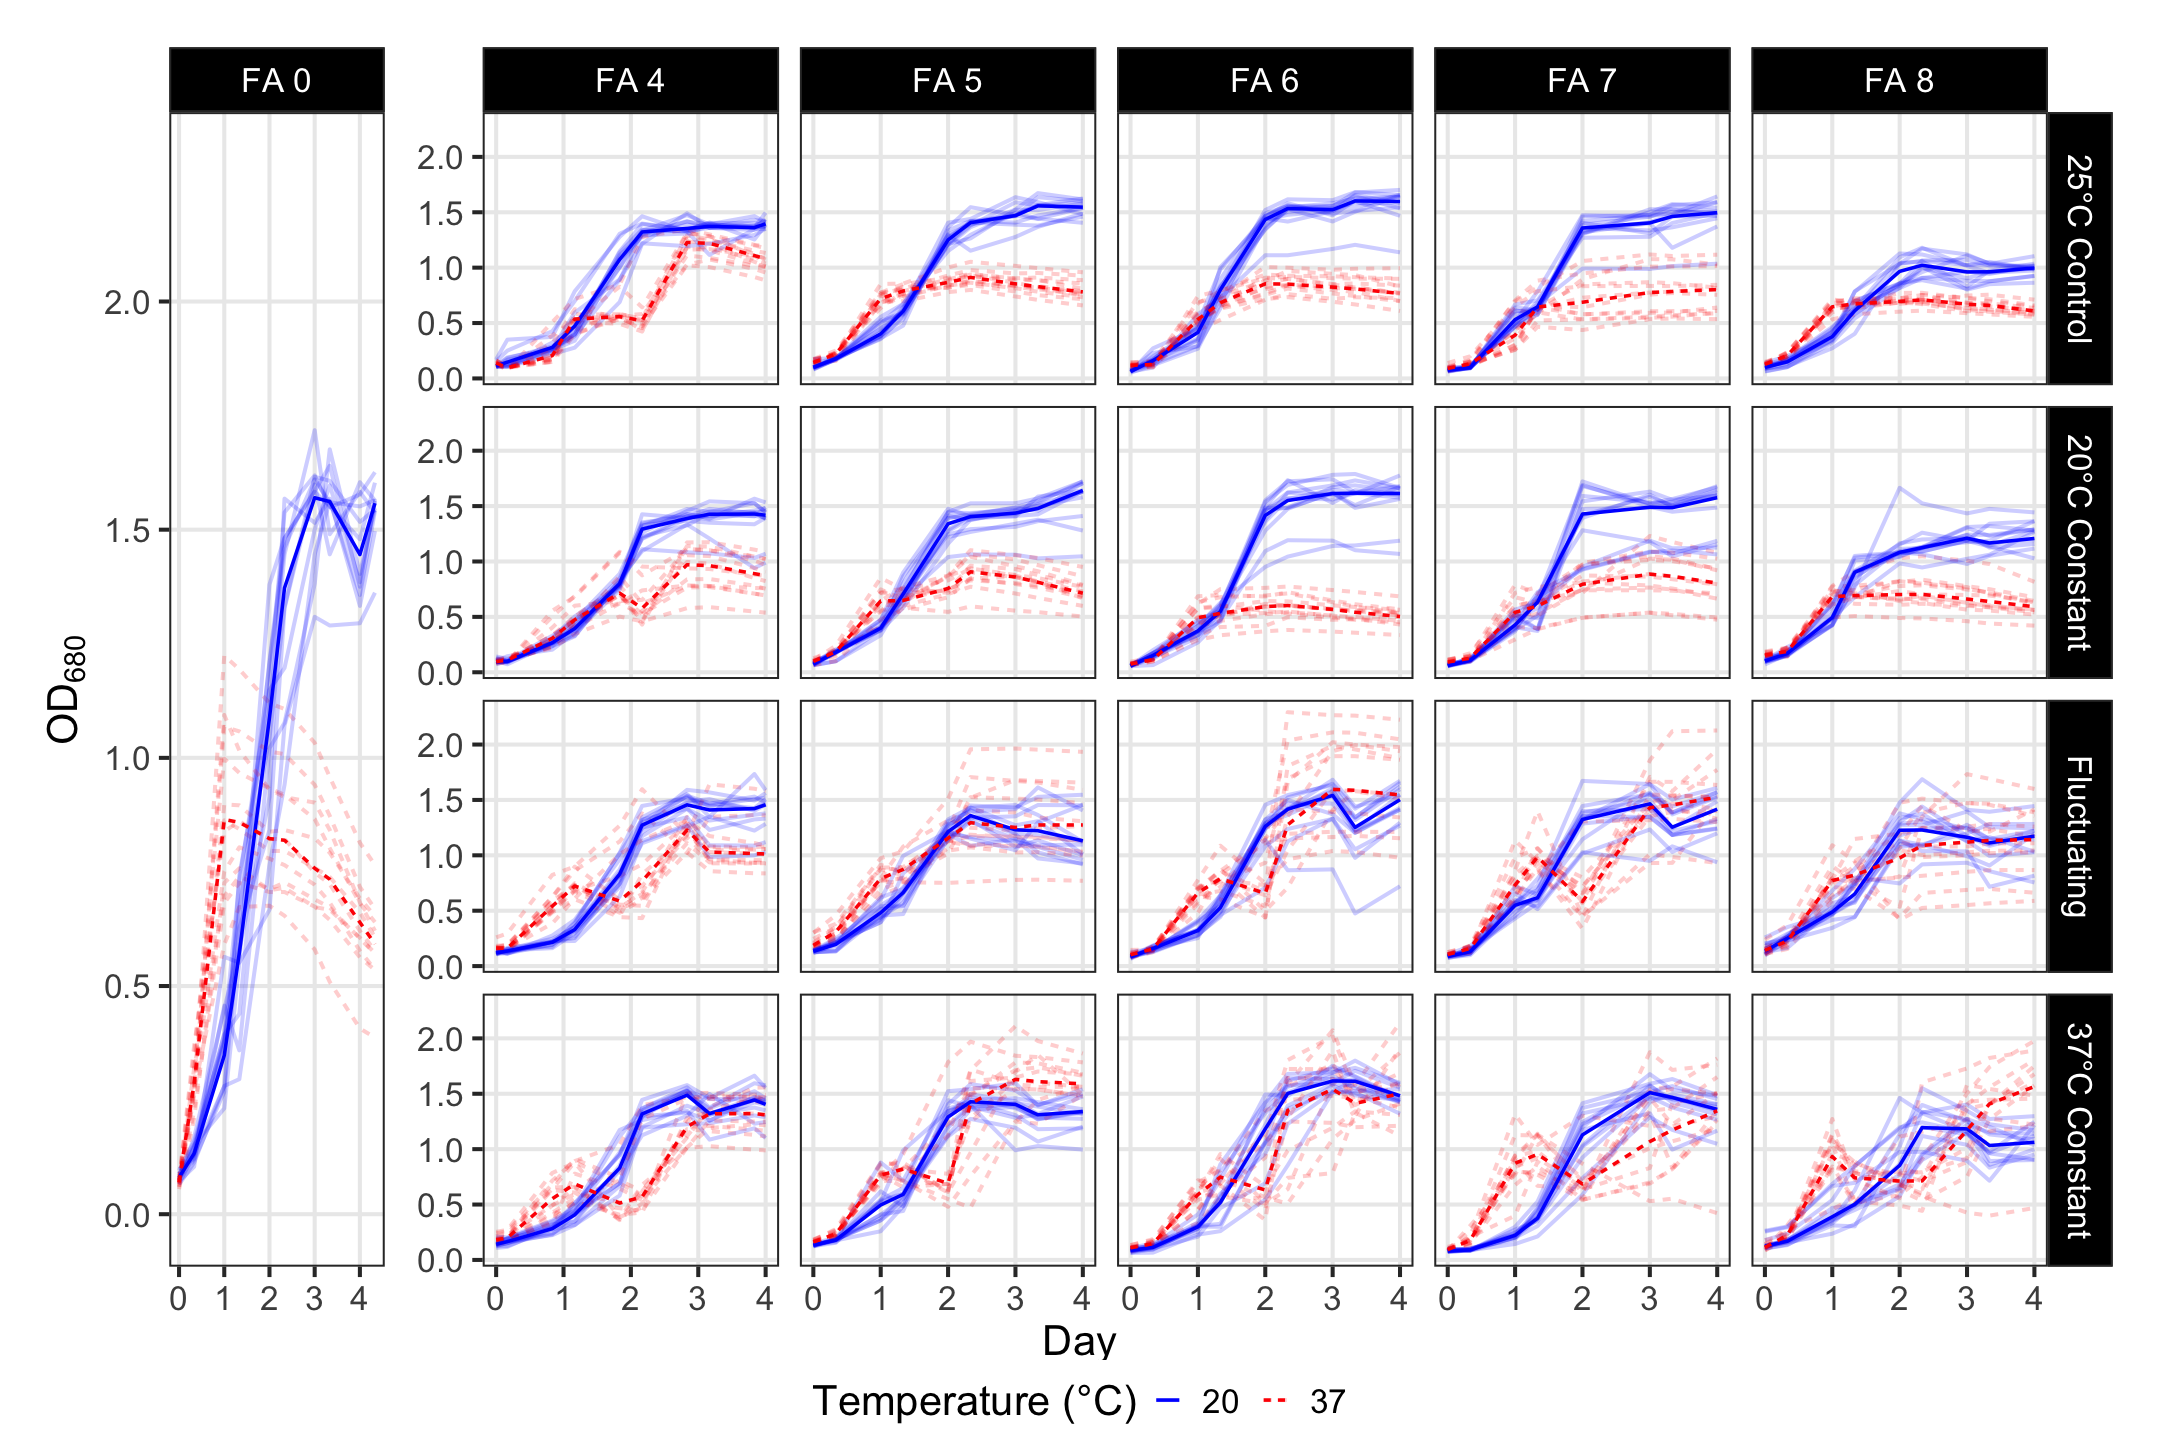

In [7]:
# Get Colony medians
FA_rawOD_colony <- HE_data %>% filter(FA %in% c(1, 5:9))%>%
    group_by(FA, Days, Condition, Temperature, Colony) %>%
    summarise(mean_rep_OD = median(OD))

# Get Condition+Temperatures medians
FA_rawOD_means <- HE_data %>% filter(FA %in% c(1, 5:9))%>%
    group_by(FA, Days, Condition, Temperature) %>%
    summarise(mean_col_OD = median(OD))
   
FA_5plus <- ggplot(FA_rawOD_colony %>% filter(FA > 1), aes(x = Days, y = mean_rep_OD, col = Temperature, group = interaction(Temperature,Colony))) +
        geom_line(alpha = 0.2, aes(linetype = Temperature))+
        geom_line(data = FA_rawOD_means %>% filter(FA > 1), aes(x = Days, y = mean_col_OD, group = Temperature, linetype = Temperature), size = 1)+
        scale_color_manual(values = c("Blue", "Red")) +
        facet_grid(Condition~FA, labeller = as_labeller(c(condition_names, `1` = "FA 0", 
                                                          `5` = "FA 4", 
                                                          `6` = "FA 5", 
                                                          `7` = "FA 6", 
                                                          `8` = "FA 7", 
                                                          `9` = "FA 8")))+
        theme_bw(25)+
        theme(strip.background=element_rect(fill="black"),
            strip.text = element_text(colour = 'white'), 
            panel.grid.minor = element_blank(),
            plot.margin=unit(c(1,1,-1,-0.7), "cm"))+ # Top, Right, Bottom, Left) +
        theme(legend.position = "none") +
        ylab(expression("")) +
        xlab("")

FA_0 <- ggplot(FA_rawOD_colony %>% filter(FA == 1, Condition == "P"), aes(x = Days, y = mean_rep_OD, col = Temperature, group = interaction(Temperature,Colony))) +
        geom_line(alpha = 0.2, aes(linetype = Temperature))+
        geom_line(data = FA_rawOD_means %>% filter(FA == 1, Condition == "P"), aes(x = Days, y = mean_col_OD, group = Temperature, linetype = Temperature), size = 1)+
        scale_color_manual(values = c("Blue", "Red")) +
        theme_bw(25)+
        facet_grid(~FA, labeller = as_labeller(c(condition_names, `1` = "FA 0", 
                                                          `5` = "FA 4", 
                                                          `6` = "FA 5", 
                                                          `7` = "FA 6", 
                                                          `8` = "FA 7", 
                                                          `9` = "FA 8")))+
        theme(strip.background=element_rect(fill="black"),
            strip.text = element_text(colour = 'white'), 
            panel.grid.minor = element_blank(),
            plot.margin=unit(c(1,1,-1,1), "cm"))+
        theme(legend.position = "bottom") +
        labs(color = "Temperature (°C)", linetype ="Temperature (°C)")+
        ylab(expression("OD"[680])) +
        xlab("") +
        ylim(0, 2.3)

options(repr.plot.width=18, repr.plot.height=12) 

grid_arrange_shared_legend(FA_0, gridExtra::arrangeGrob(FA_5plus), 
                           ncol=2, 
                           bottom = textGrob("Day", gp = gpar(fontsize = 25)), 
                          widths =c(1,4))

options(repr.plot.width=16, repr.plot.height=8) 


# Q1 + Q2: Specialists vs Control vs Plastic

In [8]:
HE_F9 <- HE_data %>% filter(FA == 9, Days == 4) 
head(HE_F9)

,Days,FA,Condition,Temperature,Colony,Rep,OD,Area
,<dbl>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>
1,4,9,20S,37,1,1,0.881,81.544
2,4,9,20S,37,1,2,0.635,66.156
3,4,9,20S,37,1,3,0.648,68.492
4,4,9,20S,37,1,4,0.816,77.908
5,4,9,20S,37,1,5,0.851,80.000
6,4,9,20S,20,1,1,1.168,88.640


## Assess Colony Effect
### Normality Test

In [9]:
for (t in c(20, 37)){
    for (c in unique(HE_F9$Condition)){
        for (col in 1:12){
            out <- HE_F9 %>% 
                filter(Temperature == t, Condition == c, Colony == col) %>% 
                pull(Area)%>%
                shapiro.test()
            if (out$p.value <= 0.05){
                print(paste(t, c, col))
            }
        }
    }
}

[1] "20 P 2"
[1] "20 P 8"
[1] "20 P 10"
[1] "37 20S 10"
[1] "37 20S 11"
[1] "37 37S 9"


### Permutation Test

[1] 2.472239

[1] 0.0517

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


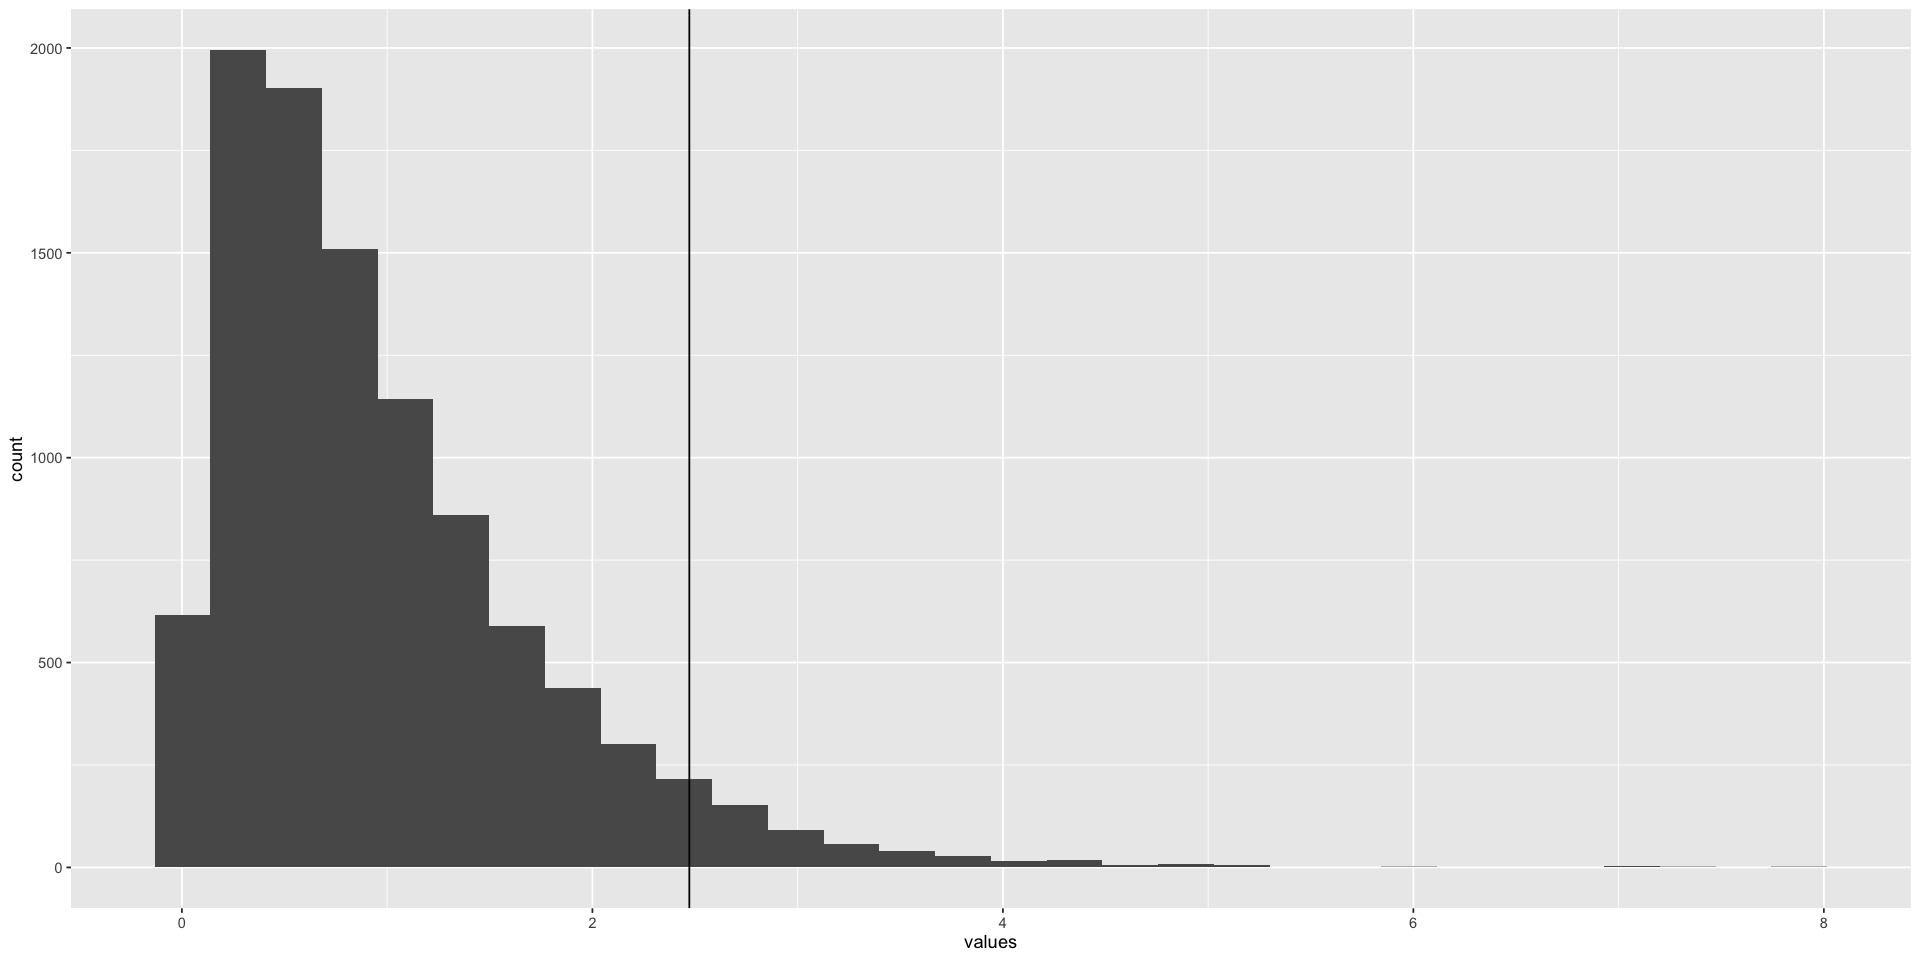

In [10]:
B <- 10000
perm_F <- numeric(B)

# observed F-statistic
obs_F <- anova(lm(Area ~ Condition + Temperature + Colony, data = HE_F9))$`F value`[3]
obs_F

for (i in 1:B) {
  HE_F9$perm_individual <- ave(HE_F9$Condition, HE_F9$Colony, #permutate Colony within condition
                            FUN = function(x) sample(x))
  perm_F[i] <- anova(lm(Area ~ Condition + Temperature + perm_individual, data = HE_F9))$`F value`[3]
}

p_value <- mean(perm_F >= obs_F)
p_value

perm_F %>% data.frame(values = .) %>%
    ggplot(aes(x = values))+
        geom_histogram() +
        geom_vline(xintercept = obs_F)

## HLM: Hierarchical linear Mixed-Effects Model
### Check Models

In [30]:
model <- lmer(Area ~ Condition * Temperature + (1|Colony) + (1|Colony:Condition) + (1|Colony:Temperature), data = HE_F9, REML=FALSE)
model_add <- lmer(Area ~ Condition + Temperature + Colony + (1|Colony:Condition) + (1|Colony:Temperature), data = HE_F9, REML=FALSE)
model_int_and_col <- lmer(Area ~ Condition * Temperature + Colony + (1|Colony:Condition) + (1|Colony:Temperature), data = HE_F9, REML=FALSE)

model.set <- list(model,model_add, model_int_and_col)
model.names <- c("model","model_add", "model_int_and_col")

aictab(model.set, modnames = model.names)

boundary (singular) fit: see help('isSingular')



,Modnames,K,AICc,Delta_AICc,ModelLik,AICcWt,LL,Cum.Wt
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,model,12,3649.427,0.00000,1.000000e+00,9.993159e-01,-1812.379,0.9993159
3,model_int_and_col,22,3664.000,14.57351,6.845467e-04,6.840784e-04,-1808.893,1.0000000
2,model_add,19,3864.589,215.16242,1.897033e-47,1.895735e-47,-1912.468,1.0000000


### Run Model

In [31]:
# model <- lmer(Area ~ Condition * Temperature + (1|Colony) + (1|Colony:Condition) + (1|Colony:Temperature), data = HE_F9) 
anova(model)
summary(model)

#Random effects
ranova(model)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
Condition,5076.332,1692.111,3,44.24119,19.02159,4.522858e-08
Temperature,1882.371,1882.371,1,16.65676,21.16037,2.680049e-04
Condition:Temperature,23940.354,7980.118,3,418.78227,89.70721,7.576361e-45


Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: 
Area ~ Condition * Temperature + (1 | Colony) + (1 | Colony:Condition) +  
    (1 | Colony:Temperature)
   Data: HE_F9

      AIC       BIC    logLik -2*log(L)  df.resid 
   3648.8    3698.8   -1812.4    3624.8       468 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.4642 -0.6111  0.0156  0.5025  4.0227 

Random effects:
 Groups             Name        Variance  Std.Dev. 
 Colony:Condition   (Intercept) 4.730e+01 6.8772013
 Colony:Temperature (Intercept) 1.183e+01 3.4399363
 Colony             (Intercept) 1.477e-07 0.0003843
 Residual                       8.896e+01 9.4317217
Number of obs: 480, groups:  
Colony:Condition, 48; Colony:Temperature, 24; Colony, 12

Fixed effects:
                           Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)                  69.354      2.532  68.284  27.393  < 2e-16 ***
Condition20S                 15.

boundary (singular) fit: see help('isSingular')



,npar,logLik,AIC,LRT,Df,Pr(>Chisq)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
<none>,12,-1812.379,3648.759,NA,NA,NA
(1 | Colony),11,-1812.379,3646.759,-1.795565e-07,1,1.000000e+00
(1 | Colony:Condition),11,-1864.719,3751.437,1.046788e+02,1,1.436329e-24
(1 | Colony:Temperature),11,-1821.944,3665.888,1.912956e+01,1,1.221387e-05


In [35]:
VarCorr(model)

 Groups             Name        Std.Dev.  
 Colony:Condition   (Intercept) 6.87720131
 Colony:Temperature (Intercept) 3.43993628
 Colony             (Intercept) 0.00038427
 Residual                       9.43172168

### Pairwise Comparisions

In [33]:
comparisons <- emmeans(model, pairwise ~ Temperature * Condition) #Results were averaged over colony
comparisons

sig_groups <- comparisons$contrasts %>% 
                data.frame() %>% 
                filter((str_count(contrast, "Temperature20") == 2 | str_count(contrast, "Temperature37") == 2), p.value < 0.05) %>% 
                separate_wider_delim(contrast, delim = " - ", names = c("Condition1", "Condition2")) %>%
                # Keep Temperature
                separate_wider_delim(Condition1, delim = " ", names = c("Temperature", "ConditionA")) %>%
                separate_wider_delim(Temperature, delim = "Temperature", names = c("x", "Temperature")) %>%
                separate_wider_delim(Condition2, delim = " ", names = c("x2", "ConditionB")) %>%
                select(-c("x", "x2")) %>% 
                mutate(Temperature = factor(Temperature)) %>% 
                arrange(Temperature)
sig_groups

boundary (singular) fit: see help('isSingular')



$emmeans
 Temperature Condition emmean   SE   df lower.CL upper.CL
 20          25S         69.4 2.64 73.6     64.1     74.6
 37          25S         56.7 2.64 73.6     51.5     62.0
 20          20S         85.1 2.64 73.6     79.9     90.4
 37          20S         57.1 2.64 73.6     51.8     62.4
 20          P           83.2 2.64 73.6     78.0     88.5
 37          P           84.7 2.64 73.6     79.5     90.0
 20          37S         75.9 2.64 73.6     70.7     81.2
 37          37S         84.8 2.64 73.6     79.5     90.1

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                              estimate   SE   df t.ratio p.value
 Temperature20 25S - Temperature37 25S  12.6433 2.28 42.4   5.545  <.0001
 Temperature20 25S - Temperature20 20S -15.7887 3.42 52.6  -4.614  0.0006
 Temperature20 25S - Temperature37 20S  12.2587 3.73 58.7   3.286  0.0343
 Temperature20 25S - Temperature20 P   -13.8850 3.42 52.6  -4.058  0.0038
 Temperature20 

Temperature,ConditionA,ConditionB,estimate,SE,df,t.ratio,p.value
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
20,25S,20S,-15.78867,3.421787,52.55888,-4.614158,6.399310e-04
20,25S,P,-13.88500,3.421787,52.55888,-4.057821,3.845354e-03
37,25S,P,-28.02393,3.421787,52.55888,-8.189853,1.632693e-09
37,25S,37S,-28.09167,3.421787,52.55888,-8.209648,1.518940e-09
37,20S,P,-27.63927,3.421787,52.55888,-8.077436,2.461241e-09
37,20S,37S,-27.70700,3.421787,52.55888,-8.097231,2.289553e-09


## Display Data

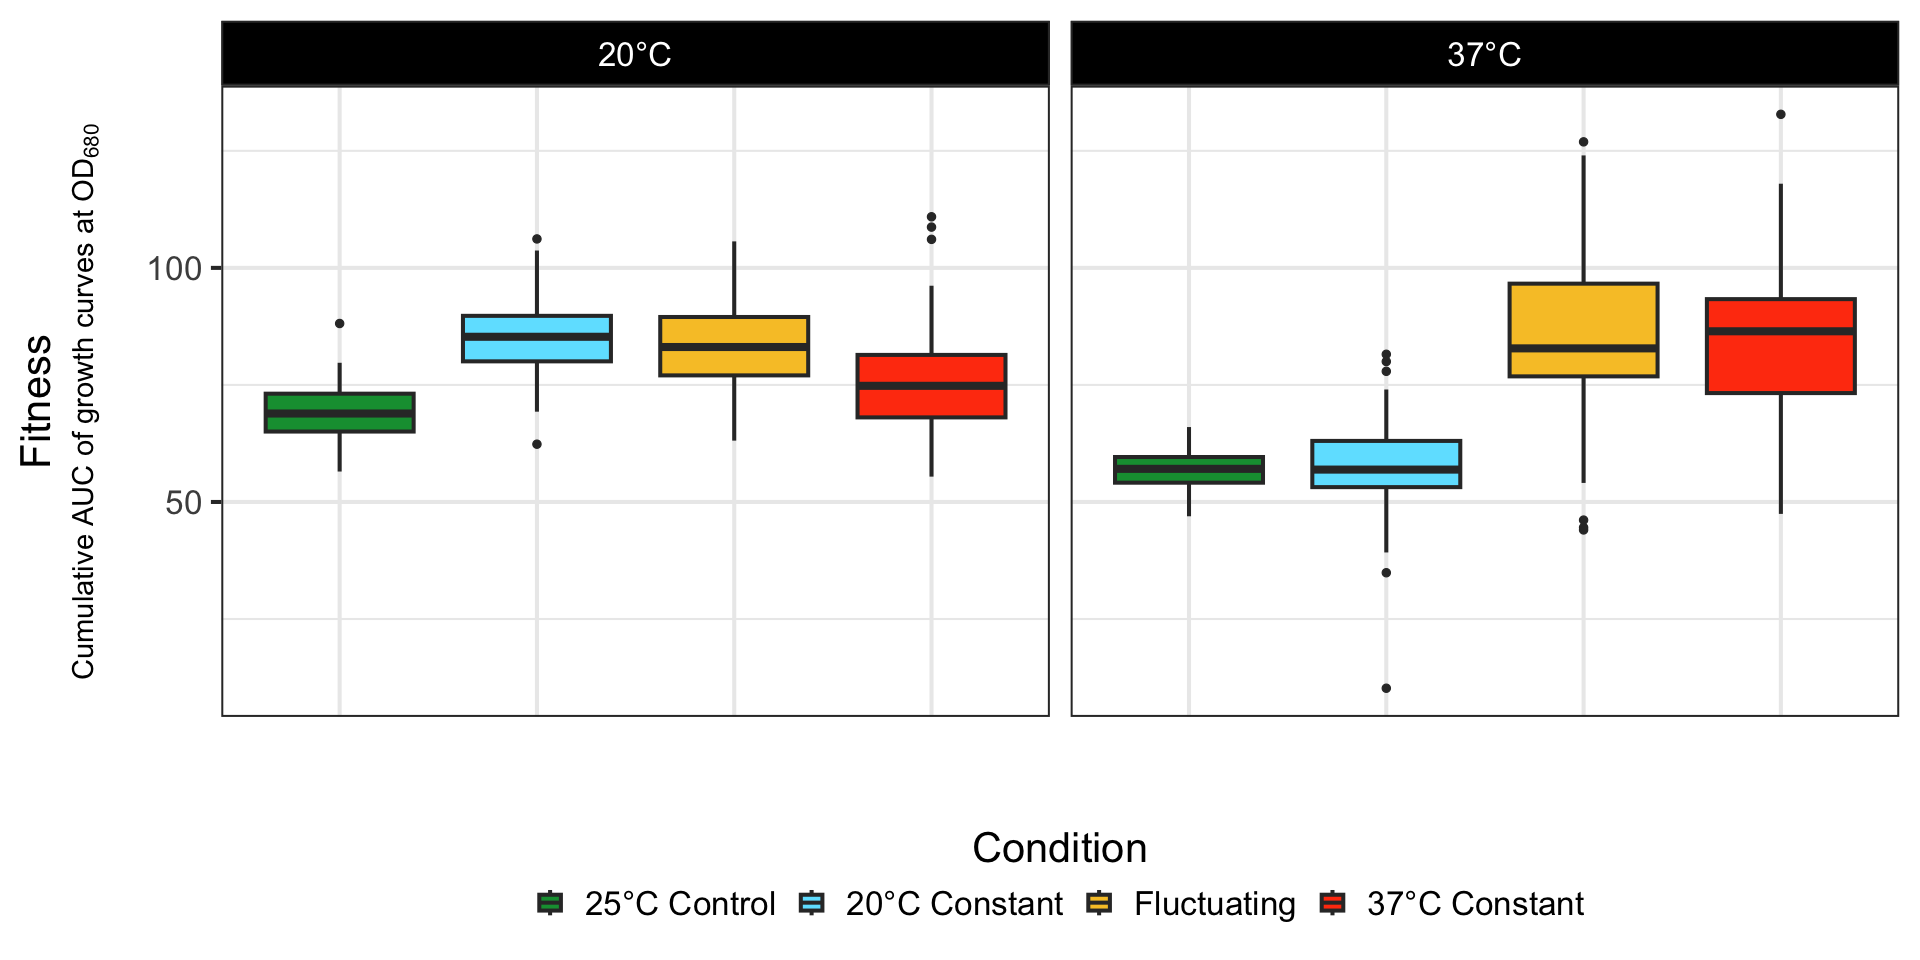

In [34]:
options(repr.plot.width=16, repr.plot.height=8) 
# Visualize the data
overall_plot <- ggplot(HE_F9, aes(x = Condition, y = Area, fill = Condition)) +
    geom_boxplot(outlier.size = 2)+
    theme_bw(25)+ #paper 25
    scale_fill_manual(values = condition_colors, labels = condition_names)+
    facet_wrap(~Temperature, labeller = as_labeller(condition_names)) + #no ncol
    theme(legend.position="bottom", 
          # legend.title = element_blank(), 
          axis.text.x = element_blank(), 
          axis.ticks.x = element_blank(), 
          strip.background=element_rect(fill="black"),
          strip.text = element_text(colour = 'white'),
          panel.background = element_rect(fill = "transparent", color=NA),
          plot.background = element_rect(fill = "transparent", color=NA), 
          legend.background = element_rect(fill='transparent')) +
    guides(fill = guide_legend(title.position = "top", title.hjust = 0.5)) +
    labs(x = "", 
         # y = "Cell Density")
         y= expression(atop("Fitness", atop("Cumulative AUC of growth curves at OD"[680]))))
overall_plot

Warning message:
“Combining variables of class <factor> and <numeric> was deprecated in ggplot2 3.4.0.
ℹ Please ensure your variables are compatible before plotting (location: `combine_vars()`)”
Warning message:
“Combining variables of class <numeric> and <factor> was deprecated in ggplot2 3.4.0.
ℹ Please ensure your variables are compatible before plotting (location: `combine_vars()`)”


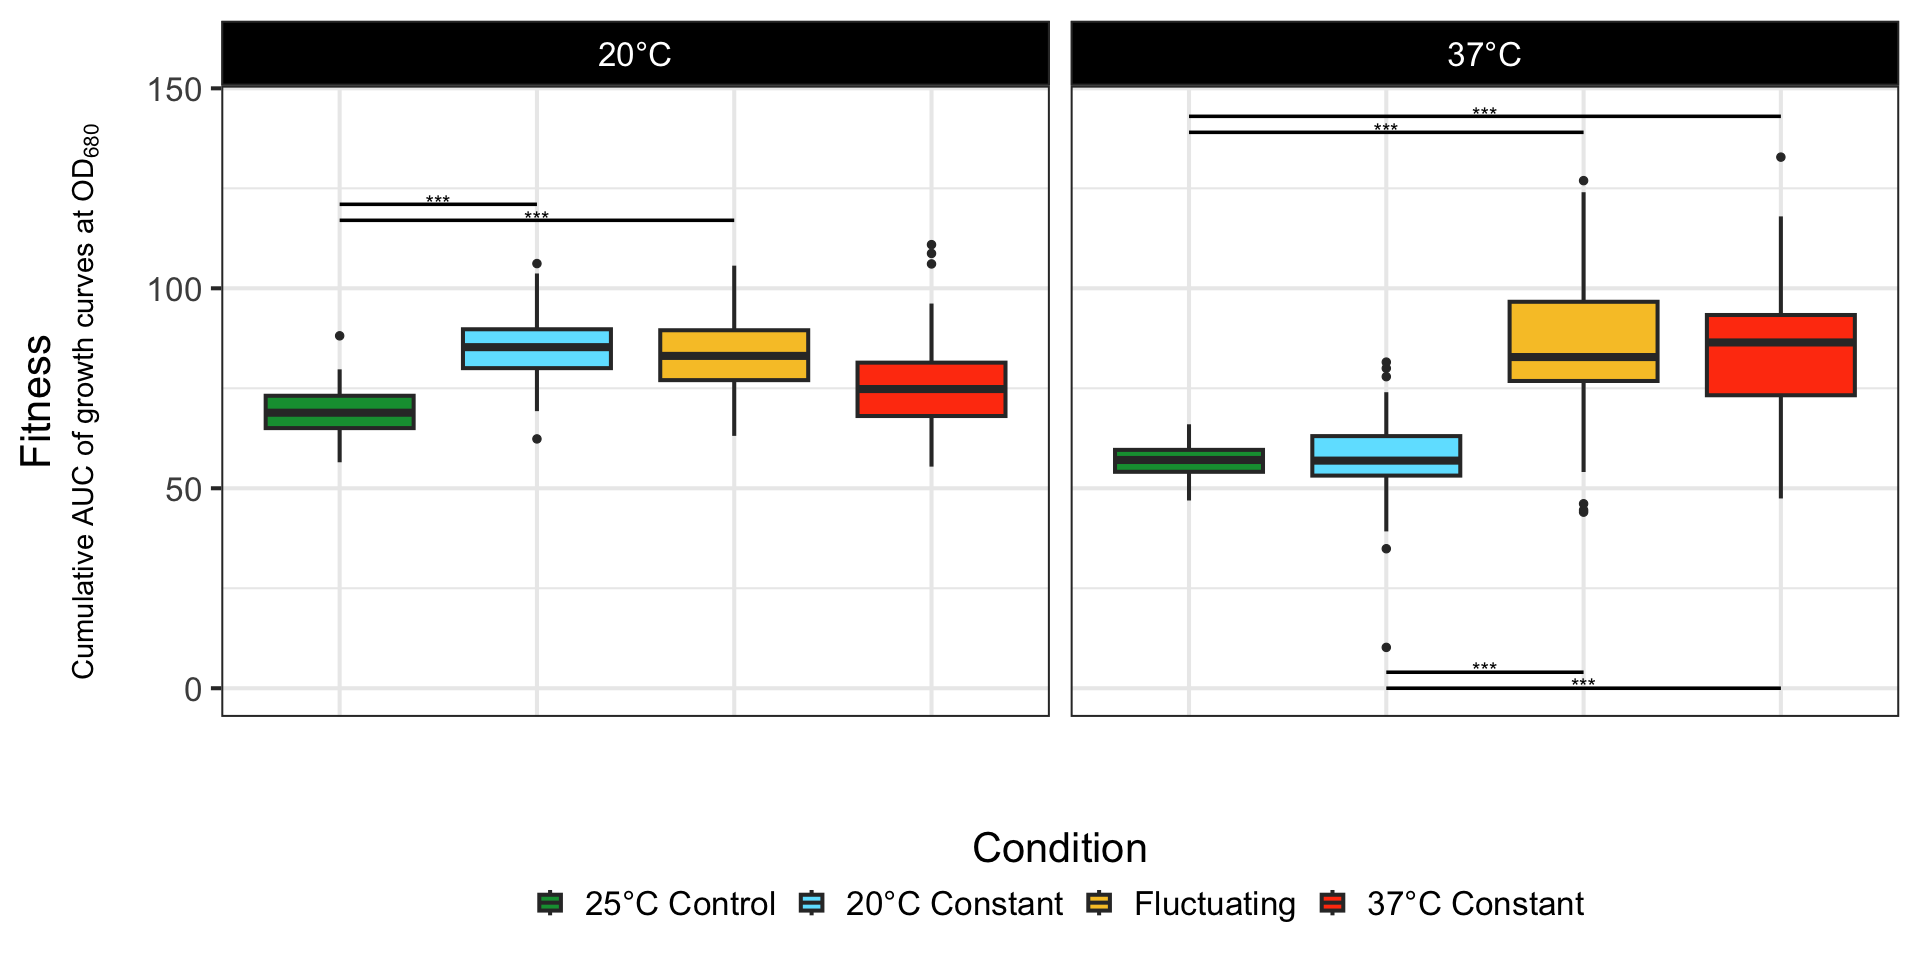

In [14]:
star_start <- c(1, 1, 1, 1, 2, 2) #20, 20, 37, 37, 37, 37
star_end <- c(2, 3, 3, 4, 3, 4) #20, 20, 37,37,37,37
star_middle <- (star_start + star_end) /2

star_lines <- data.frame(x = star_start, 
                        xend = star_end, 
                        y = c(121, 117, 139, 143, 4, 0), 
                        yend = c(121, 117, 139, 143, 4, 0), 
                        Temperature = c(20, 20, 37, 37, 37, 37))
star_placement <- data.frame(x = star_middle, 
                        y = c(121, 117, 139, 143, 4, 0) + 0.5, 
                        Temperature = c(20, 20, 37, 37, 37, 37), 
                        label = c("***","***","***","***","***","***"))

overall_plot_stars <- overall_plot +
    geom_segment(data = star_lines, aes(x = x, xend = xend, y = y, yend = yend), inherit.aes = FALSE, size = 1) +
    geom_text(data = star_placement, mapping = aes(x = x, y = y, label = label, size = 2), inherit.aes = FALSE, show.legend = F) +
    labs(x = "")
    # scale_y_continuous(position = "right")
overall_plot_stars
ggsave('~/Desktop/overall_plot_stars.png', overall_plot_stars, bg='transparent', height = 8, width = 16)


In [15]:
# What's the percent increase between all relative to controls? within a temperature
HE_F9 %>% 
    group_by(Temperature, Condition) %>% 
    summarize(Median = median(Area)) %>%
    mutate(norm = Median/Median[Condition=="25S"]) 

`summarise()` has grouped output by 'Temperature'. You can override using the `.groups` argument.


Temperature,Condition,Median,norm
<fct>,<fct>,<dbl>,<dbl>
20,25S,68.892,1.0000000
20,20S,85.284,1.2379376
20,P,83.096,1.2061778
20,37S,74.808,1.0858735
37,25S,57.074,1.0000000
37,20S,56.914,0.9971966
37,P,82.808,1.4508883
37,37S,86.458,1.5148404


# Q3: Does fluctuating environment lead to more variation?
## Variation within Temperature

In [16]:
# Run multiple comparisons 
# Compare the conditions with each other within a temperature 

pairs <- list(c("P", "37S"), c("P", "20S"), c("20S", "37S"), c("P", "25S"), c("20S", "25S"), c("37S", "25S"))
pvals <- c()
fvals <- c()

for (temp in c(20, 37)){ # do for within a Temperature
    for (i in 1:length(pairs)){

        #Subset the data
        subset_data <- HE_data_norm %>% filter(FA == 9, Days == 4, Temperature == temp, Condition %in% pairs[[i]])

        #Run a Levenes test
        test <- leveneTest(Area ~ Condition, subset_data)
        
        # Store the p-value
        pvals <- c(pvals, test$'Pr(>F)'[1])

        # Store the f-value
        fvals <- c(fvals, test$"F value"[1])
        
    }
}

In [17]:
# Get Bonferroni-adjusted p-values:
adjusted_pvals <- p.adjust(pvals, method="bonferroni")
adjusted_pvals

[1] 1.000000e+00 1.000000e+00 2.782670e-01 3.462214e-03 3.964164e-01
 [6] 1.020749e-03 1.000000e+00 1.516976e-03 1.242269e-02 7.574393e-10
[11] 5.617850e-03 1.484405e-08

In [18]:
# Clean it up
temp_pvals <- data.frame(Temperature = c(rep(20, 6), rep(37, 6)), 
                         Pairs = c(rep(c("Fluctuating, C37", "Fluctuating, C20", "C20, C37", "Fluctuating, C25", "C20, C25", "C37, C25"), 2)),
                         F = round(fvals, 2),
                         pvals, 
                         adjusted_pvals = round(adjusted_pvals, 4))
temp_pvals 
# temp_pvals %>% filter(adjusted_pvals <= 0.05)

Temperature,Pairs,F,pvals,adjusted_pvals
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
20,"Fluctuating, C37",0.57,4.518597e-01,1.0000
20,"Fluctuating, C20",2.87,9.303475e-02,1.0000
20,"C20, C37",5.29,2.318892e-02,0.2783
20,"Fluctuating, C25",13.97,2.885178e-04,0.0035
20,"C20, C25",4.65,3.303470e-02,0.3964
20,"C37, C25",16.57,8.506239e-05,0.0010
37,"Fluctuating, C37",0.34,5.595153e-01,1.0000
37,"Fluctuating, C20",15.72,1.264147e-04,0.0015
37,"C20, C37",11.32,1.035224e-03,0.0124


## Variation Between Temperatures

In [19]:
pvals <- c()
fvals <- c()

for (cond in c("P", "37S", "20S", "25S")){ # do for between Temperatures
        #Subset the data
        subset_data <- HE_data_norm %>% filter(FA == 9, Days == 4, Condition == cond)

        #Run a Levenes test
        test <- leveneTest(Area ~ Temperature, subset_data)
        
        # Store the p-value
        pvals <- c(pvals, test$'Pr(>F)'[1])

        # Store the f-value
        fvals <- c(fvals, test$"F value"[1])

}
# Run Bonferroni correction
adjusted_pvals <- p.adjust(pvals, method="bonferroni")
adjusted_pvals

cond_pvals <- data.frame(Condition = c("P", "37S", "20S", "25S"), 
                         F = round(fvals, 2),
                         pvals, 
                         adjusted_pvals = round(adjusted_pvals, 4))
cond_pvals 

[1] 0.001767787 0.106344854 1.000000000 0.112693722

Condition,F,pvals,adjusted_pvals
<chr>,<dbl>,<dbl>,<dbl>
P,13.07,0.0004419468,0.0018
37S,5.04,0.0265862136,0.1063
20S,0.48,0.4912711847,1.0000
25S,4.94,0.0281734306,0.1127


## Plot Variation

`summarise()` has grouped output by 'Temperature', 'Condition'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'Temperature'. You can override using the `.groups` argument.

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




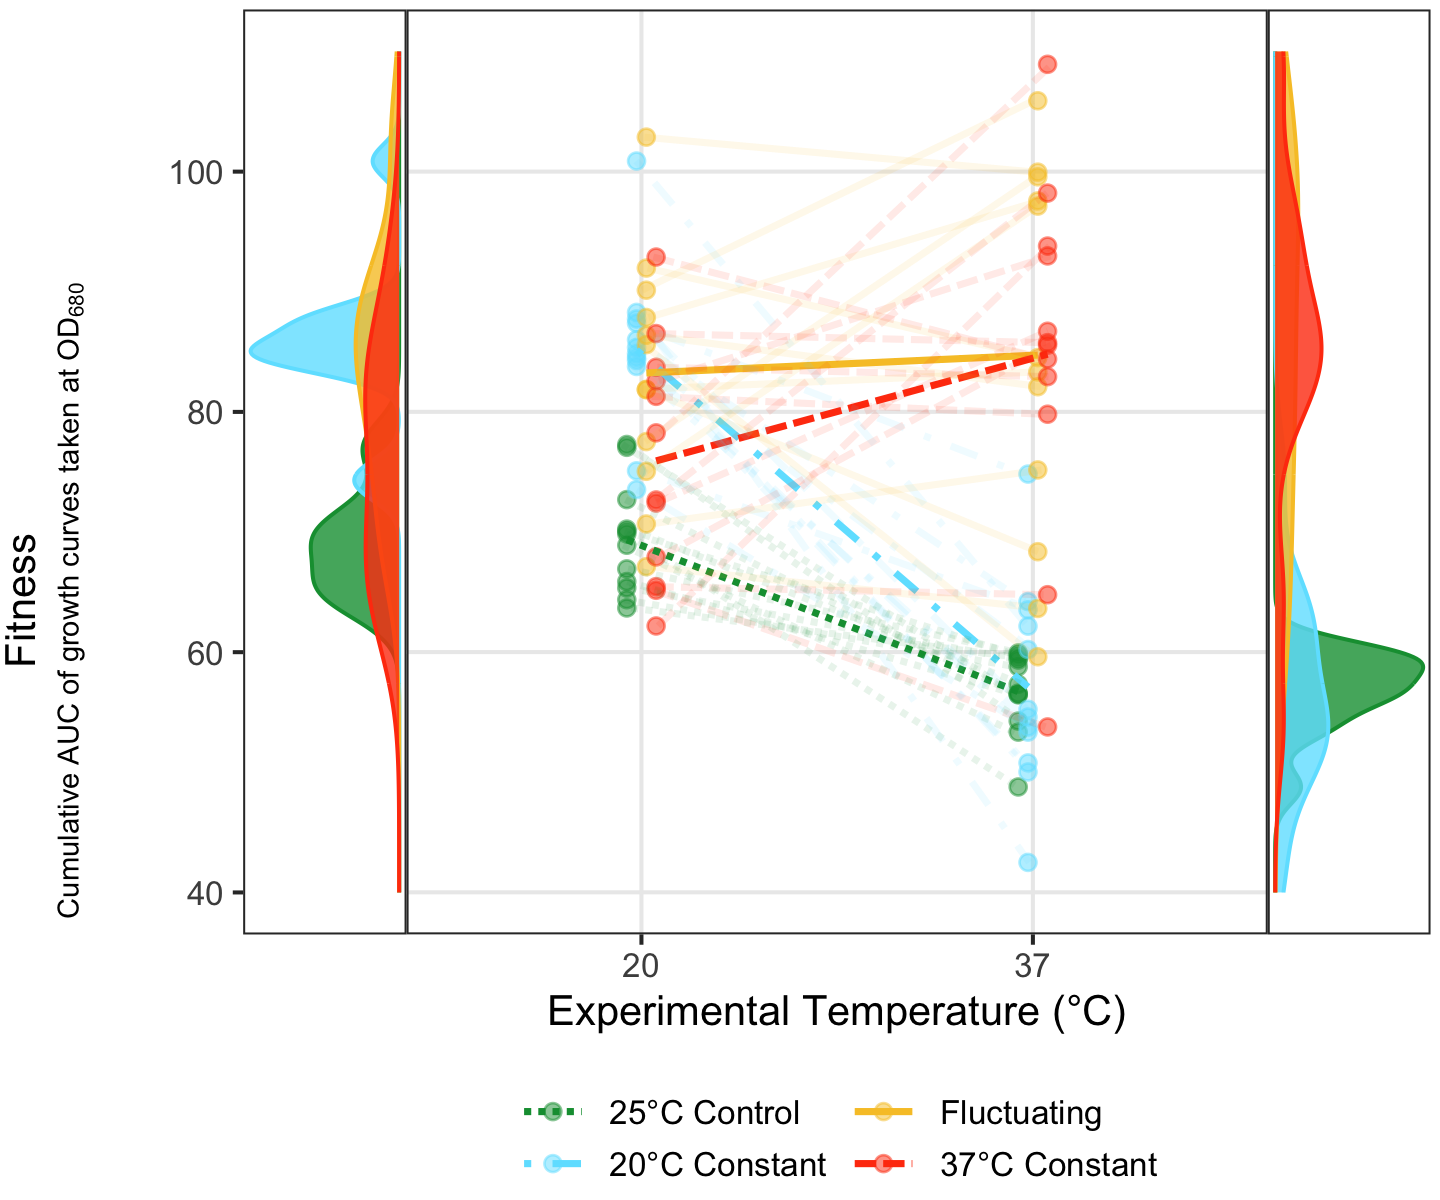

In [20]:
options(repr.plot.width=12, repr.plot.height=10) 

scaled_means_colony <- HE_data_norm %>%
                filter(FA == 9, Days == 4) %>%
                group_by(Temperature, Condition, Colony) %>% summarize(Mean = mean(Area))

# Get the means of every condition
scaled_means_condition <- HE_data_norm %>% 
                filter(FA == 9, Days == 4) %>%
                group_by(Temperature, Condition) %>% summarize(Mean = mean(Area))


# Make the main plot
compare_plot <- ggplot(scaled_means_colony, aes(x = Temperature, y = Mean, linetype = Condition, col = Condition, group = Condition))+
    theme_bw(25)+
    scale_color_manual(values = condition_colors, labels = condition_names)+
    geom_point(size = 4, alpha = 0.5, position = position_dodge(width = 0.1))+
    geom_line(data = scaled_means_condition, 
              aes(x = Temperature, y = Mean, col = Condition), 
              size = 2, position = position_dodge(width = 0.1)) +
    geom_line(aes(x = Temperature, y = Mean, group = interaction(Colony, Condition)), 
              alpha = 0.1, size = 2, position = position_dodge(width = 0.1)) +
    scale_linetype_manual(values = condition_lines, labels = condition_names) + 
    theme(legend.title = element_blank(),
          legend.position="bottom",
          legend.key.width = unit(3, "line"),
          axis.title.y=element_blank(), 
          axis.text.y=element_blank(),
          axis.ticks.y=element_blank(),
          panel.grid.minor.x = element_blank(), 
          panel.grid.minor.y = element_blank(),
          panel.background = element_rect(fill = "transparent", color=NA),
          plot.background = element_rect(fill = "transparent", color=NA),
          plot.margin=unit(c(0.2,0,0,0), "cm"))+ # Top, Right, Bottom, Left
    guides(color = guide_legend(ncol = 2))+
    labs(x = "Experimental Temperature (°C)")+
    ylim(40, 110)

margin_20 <- scaled_means_colony %>% 
filter(Temperature == 20) %>%
ggplot(aes(y = Mean, fill = Condition, color = Condition))+
    geom_density(alpha = 0.8)+
    theme_bw(base_size = 25) +
    scale_fill_manual(values = condition_colors, labels = condition_names)+
    scale_color_manual(values = condition_colors, labels = condition_names)+
    theme(axis.title.x=element_blank(), axis.text.x=element_blank(),axis.ticks.x=element_blank(), 
          legend.position = "none", 
          panel.grid.major.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.x = element_blank(), 
          panel.grid.minor.y = element_blank(),
          panel.background = element_rect(fill = "transparent", color=NA),
          plot.background = element_rect(fill = "transparent", color=NA),
          plot.margin=unit(c(0.2,0,5.62,0), "cm"))+ # Top, Right, Bottom, Left
    labs(y = "") + #expression(atop("Fitness", atop("Cell Density Relative To 25°C Control"))))+
    scale_x_reverse()+
    ylim(40, 110)

margin_37 <- scaled_means_colony %>% 
filter(Temperature == 37) %>%
ggplot(aes(y = Mean, fill = Condition, col = Condition))+
    geom_density(alpha = 0.8)+
    theme_bw(base_size = 25) +
    scale_fill_manual(values = condition_colors, labels = condition_names)+
    scale_color_manual(values = condition_colors, labels = condition_names)+
    theme(axis.title.y=element_blank(), axis.text.y=element_blank(),axis.ticks.y=element_blank(), 
          axis.title.x=element_blank(), axis.text.x=element_blank(),axis.ticks.x=element_blank(), 
          legend.position = "none", 
          plot.margin=unit(c(0.2,0.2,5.62,0), "cm"), # Top, Right, Bottom, Left
          panel.grid.major.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.x = element_blank(), 
          panel.grid.minor.y = element_blank(),
          panel.background = element_rect(fill = "transparent", color=NA),
          plot.background = element_rect(fill = "transparent", color=NA),)+
    ylim(40, 110)


library(gridExtra)
library(grid)

p <- plot_grid(margin_20, compare_plot, margin_37, ncol=3, rel_widths = c(1/3, 1, 1/5))

y.grob <- textGrob(expression(atop("Fitness", atop("Cumulative AUC of growth curves taken at OD"[680]))), 
                   gp=gpar(fontsize=25), rot=90)

grid.arrange(arrangeGrob(p, left = y.grob))


# Misc Checks
## T<sub>opt</sub> overlap
- Out of all the strains that we measured, each strain has a 62% chance of overlapping optima with another strain

In [21]:
# Get Topts
TOpt <- data.frame(read_delim("../../Temperature_Screen/Topt_ranges.txt", '\t'))
TOpt
TOpt %>% pull(topt) %>% mean()

Rows: 10 Columns: 4
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): Cell_Line
dbl (3): low, high, topt

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Cell_Line,low,high,topt
<chr>,<dbl>,<dbl>,<dbl>
CC1690,31.78298,32.187,31.901
CC1691,31.77298,32.325,32.043
CC1952,32.14800,32.667,32.405
CC2342,30.94500,31.527,31.179
CC2343,31.31500,31.731,31.527
CC2344,31.47400,32.356,31.839
CC2931,31.68200,32.386,31.981
CC3059,31.63998,32.014,31.826
CC4532,31.31400,31.529,31.416


[1] 31.8136

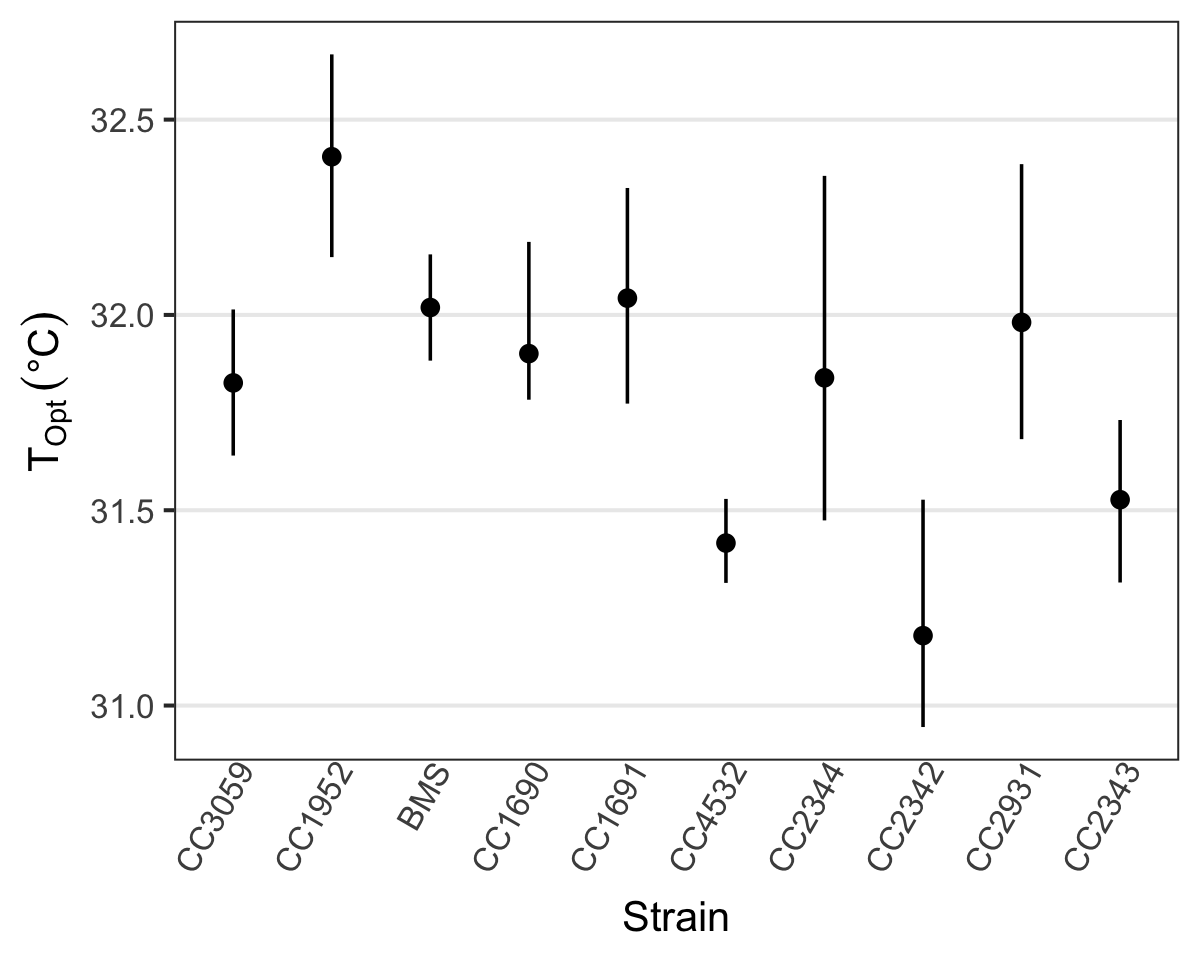

In [22]:
options(repr.plot.width=10, repr.plot.height=8) 

topt_plot <- TOpt %>%
    mutate(Cell_Line = factor(Cell_Line, levels = c("CC3059", "CC1952", "BMS", "CC1690", "CC1691", "CC4532", "CC2344", "CC2342", "CC2931", "CC2343"))) %>%
    ggplot(aes(x = Cell_Line))+
    geom_point(data = TOpt, aes(x = Cell_Line, y = topt), size = 4)+
    theme_bw(base_size = 25) +
    theme(panel.grid.minor = element_blank(), 
         panel.grid.major.x = element_blank(), 
        axis.ticks.x = element_blank(),
         axis.text.x = element_text(angle = 60, hjust = 1, vjust = 1.1))+
    labs(x = "Strain", y = expression("T"["Opt "]("°C")))+
    geom_linerange(aes(ymin = low, ymax = high), size = 1)

topt_plot

In [23]:
counter <- c()
counter_i <- 0
# Run comparative for loop
for (i in 1:9){ #Don't have to do the last cell line since not comparing with itself
    # Extract the range
    range_i <- c(TOpt[i, ]$low, TOpt[i, ]$high)

    for (j in (i+1):10){ # Don't compare with itself
        # Get range
        range_j <- c(TOpt[j, ]$low, TOpt[j, ]$high)

        counter_i <- counter_i + 1
        counter[counter_i] <- range_i %overlaps% range_j
    }
}

In [24]:
counter

[1]  TRUE  TRUE FALSE FALSE  TRUE  TRUE  TRUE FALSE  TRUE  TRUE FALSE FALSE
[13]  TRUE  TRUE  TRUE FALSE  TRUE FALSE FALSE  TRUE  TRUE FALSE FALSE  TRUE
[25]  TRUE  TRUE FALSE FALSE  TRUE FALSE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE
[37]  TRUE  TRUE  TRUE  TRUE FALSE  TRUE FALSE  TRUE FALSE

In [25]:
sum(counter)/length(counter)

[1] 0.6222222